In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
!pip install datasets==3.6.0



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 18.9 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [ ]:
MODEL_ID = "openai/whisper-small"
LANGUAGE = "bengali"
LANG_CODE = "bn"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_LABEL_LEN = 300
BATCH_SIZE = 8
LR = 1e-5
OUT_DIR = "whisper-small-bengali"

!pip install evaluate
!pip install jiwer

from datasets import load_dataset, concatenate_datasets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
from scipy.signal import resample
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader


from transformers import WhisperTokenizer
from transformers import WhisperFeatureExtractor
from transformers import WhisperForConditionalGeneration

import evaluate

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

from jiwer import cer



def down_sample_audio(audio_original, original_sample_rate):
    target_sample_rate = 16000

    # Calculate the number of samples for the target sample rate
    num_samples = int(len(audio_original) * target_sample_rate / original_sample_rate)

    # Resample the audio array to the target sample rate
    downsampled_audio = resample(audio_original, num_samples)

    return downsampled_audio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.4 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!pip install datasets[audio] transformers accelerate evaluate jiwer librosa

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from datasets import load_dataset

# Add trust_remote_code=True to allow the fleurs.py script to run
fleurs_bn = load_dataset(
    "google/fleurs",
    "bn_in",
    split="train",
    streaming=True,
    trust_remote_code=True
)

# To see a sample:
sample = next(iter(fleurs_bn))
print(f"Transcription: {sample['transcription']}")


README.md: 0.00B [00:00, ?B/s]

fleurs.py: 0.00B [00:00, ?B/s]

Transcription: এক মাইলের কম থেকে শুরু করে বেশি দূরত্ব যা কিনা একদিনে পাড়ি দেয়া যায় ততটুকু পর্যন্ত দৈনিক পদব্রজে ভ্রমণের অন্তর্ভুক্ত


In [ ]:
from transformers import WhisperTokenizer, WhisperFeatureExtractor, WhisperForConditionalGeneration

tokenizer = WhisperTokenizer.from_pretrained(
    MODEL_ID,
    language=LANGUAGE,
    task="transcribe"
)

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_ID)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID).to(DEVICE)
model.generation_config.language = LANGUAGE
model.generation_config.task = "transcribe"

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

...

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

In [ ]:
bengali_text = "হ্যালো, আপনি কেমন আছেন?"
tokenized_text = tokenizer(bengali_text)
tokenizer.decode(tokenized_text.input_ids)

'<|startoftranscript|><|bn|><|transcribe|><|notimestamps|>হ্যালো, আপনি কেমন আছেন?<|endoftext|>'

In [ ]:
from datasets import load_dataset

# Add trust_remote_code=True to allow the fleurs.py script to run
fleurs_bn = load_dataset(
    "google/fleurs",
    "bn_in",
    split="train",
    streaming=True,
    trust_remote_code=True
)

# To see a sample:
sample = next(iter(fleurs_bn))
print(f"Transcription: {sample['transcription']}")


Transcription: এক মাইলের কম থেকে শুরু করে বেশি দূরত্ব যা কিনা একদিনে পাড়ি দেয়া যায় ততটুকু পর্যন্ত দৈনিক পদব্রজে ভ্রমণের অন্তর্ভুক্ত


In [ ]:
train_data = fleurs_bn

In [ ]:
print(f"Transcription of loaded data: {sample['transcription']}")
sample

Transcription of loaded data: এক মাইলের কম থেকে শুরু করে বেশি দূরত্ব যা কিনা একদিনে পাড়ি দেয়া যায় ততটুকু পর্যন্ত দৈনিক পদব্রজে ভ্রমণের অন্তর্ভুক্ত


{'id': 813,
 'num_samples': 163200,
 'path': None,
 'audio': {'path': 'train/10007728875760582479.wav',
  'array': array([0.        , 0.        , 0.        , ..., 0.00477225, 0.00368434,
         0.00630349]),
  'sampling_rate': 16000},
 'transcription': 'এক মাইলের কম থেকে শুরু করে বেশি দূরত্ব যা কিনা একদিনে পাড়ি দেয়া যায় ততটুকু পর্যন্ত দৈনিক পদব্রজে ভ্রমণের অন্তর্ভুক্ত',
 'raw_transcription': 'এক মাইলের কম থেকে শুরু করে বেশি দূরত্ব যা কিনা একদিনে পাড়ি দেয়া যায় ততটুকু পর্যন্ত দৈনিক পদব্রজে ভ্রমণের অন্তর্ভুক্ত।',
 'gender': 1,
 'lang_id': 8,
 'language': 'Bengali',
 'lang_group_id': 4}

In [ ]:
text = sample['transcription']
tok_sentence = tokenizer(text)
tok_sentence

{'input_ids': [50258, 50302, 50359, 50363, 29045, 237, 29045, 243, 220, 29045, 106, 29045, 122, 29045, 229, 29045, 110, 156, 100, 229, 156, 12811, 220, 29045, 243, 29045, 106, 220, 29045, 98, 156, 100, 229, 29045, 243, 156, 100, 229, 220, 29045, 114, 156, 25787, 156, 12811, 156, 25787, 220, 29045, 243, 156, 12811, 156, 100, 229, 220, 156, 2250, 156, 100, 229, 29045, 114, 29045, 123, 220, 29045, 99, 156, 100, 224, 156, 12811, 29045, 97, 156, 100, 235, 156, 2250, 220, 29045, 107, 29045, 122, 220, 29045, 243, 29045, 123, 29045, 101, 29045, 122, 220, 29045, 237, 29045, 243, 29045, 99, 29045, 123, 29045, 101, 156, 100, 229, 220, 29045, 103, 29045, 122, 29045, 94, 156, 15773, 29045, 123, 220, 29045, 99, 156, 100, 229, 29045, 107, 156, 15773, 29045, 122, 220, 29045, 107, 29045, 122, 29045, 107, 156, 15773, 220, 29045, 97, 29045, 97, 29045, 253, 156, 25787, 29045, 243, 156, 25787, 220, 29045, 103, 156, 12811, 156, 100, 235, 29045, 107, 29045, 101, 156, 100, 235, 29045, 97, 220, 29045, 99, 156,

In [ ]:
from IPython.display import clear_output
import time

for idx in range(len(tok_sentence.input_ids)):
    print(tokenizer.decode(tok_sentence.input_ids[:idx]))
    clear_output(wait=True)
    time.sleep(.1)

<|startoftranscript|><|bn|><|transcribe|><|notimestamps|>এক মাইলের কম থেকে শুরু করে বেশি দূরত্ব যা কিনা একদিনে পাড়ি দেয়া যায় ততটুকু পর্যন্ত দৈনিক পদব্রজে ভ্রমণের অন্তর্ভুক্ত


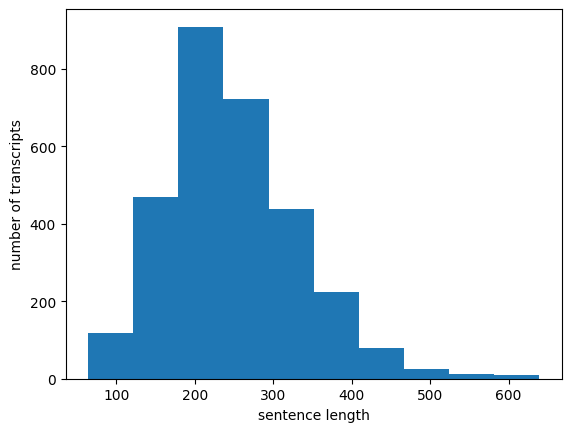

In [ ]:
list_of_transcription_lengths = []

for sample_item in train_data: # Iterate directly over the streaming dataset
    transcription = sample_item['transcription']
    tokenized_sentence = tokenizer(transcription).input_ids
    list_of_transcription_lengths.append(len(tokenized_sentence))

plt.hist(list_of_transcription_lengths)
plt.xlabel("sentence length")
plt.ylabel("number of transcripts")
plt.show()

In [ ]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)

# Since you're streaming, use .take(5) to get the first 5 items
for idx, sample in enumerate(train_data.take(5)):

    target = sample['transcription']
    audio_data = sample['audio']['array']

    # Preprocess & Move input to GPU
    input_feature = feature_extractor(
        raw_speech=audio_data,
        sampling_rate=16000,
        return_tensors='pt'
    ).input_features.to(DEVICE) # Move features to GPU

    with torch.no_grad():
        # Generate with GPU acceleration
        op = model.generate(input_feature, language='bengali', task='transcribe')

    text_pred = tokenizer.batch_decode(op, skip_special_tokens=True)[0]

    print(f'------- Sample {idx} ------')
    print(f'True : {target}')
    print(f'Pred : {text_pred}\n')

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

------- Sample 0 ------
True : এক মাইলের কম থেকে শুরু করে বেশি দূরত্ব যা কিনা একদিনে পাড়ি দেয়া যায় ততটুকু পর্যন্ত দৈনিক পদব্রজে ভ্রমণের অন্তর্ভুক্ত
Pred :  ស្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្

------- Sample 1 ------
True : ব্রাজিলের জাতীয় কংগ্রেস সামাজিক বিবাহকে 10 বছরের জন্য বৈধ করার জন্য বিতর্ক চালিয়েছে যেখানে বর্তমানে এই ধরনের বিবাহ শুধুমাত্র রিও গ্র্যান্ডে দো সুল-এ বৈধ
Pred :  BRAJILE JATIYO KONGRES, SHAMAJIK BIBHAHO KE DALBASARE JONNU BAUIDO KARAJONNU BITARU KO CHALI E CHE, JE KHANE BATTU MANE EI DHARONER BIBHAHO SHULU MATRU RIO GRANDE DO SUL E BAUIDO.

------- Sample 2 ------
True : স্থলরেখা থেকে অনেক দূরে থাকায় মার্কিন যুক্তরাষ্ট্র বা ক্যারিবিয়ানদের উপর ঝড়ের সম্ভাব্য প্রভাব মূল্যায়ন করা কঠিন হয়ে যায়
Pred :  ស្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្្

-

In [ ]:
import torch

class whisper_training_dataset(torch.utils.data.IterableDataset):
    def __init__(self, dataset, max_len):#daatset is huggingface dataset object
        self.dataset = dataset
        self.max_len = max_len
        self.bos_token = model.config.decoder_start_token_id

    def __iter__(self):
        for item in self.dataset:

            audio_data = down_sample_audio(item['audio']["array"], item['audio']["sampling_rate"])
            input_features = feature_extractor(audio_data, sampling_rate=16000,return_tensors='pt').input_features[0]

            # Process the transcription
            transcription = item["transcription"]

            # Create labels
            labels = tokenizer(transcription, padding="max_length", max_length=self.max_len, truncation=True, return_tensors="pt")
            labels = labels["input_ids"].masked_fill(labels['attention_mask'].ne(1), -100)
            labels = labels[0][1:]


            yield {
                "input_features": input_features,
                "labels": labels
            }

print("Class 'whisper_training_dataset' defined successfully.")

Class 'whisper_training_dataset' defined successfully.


In [ ]:
dataset = whisper_training_dataset(dataset=train_data, max_len=300)

train_dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=8,
    # Shuffle is not directly supported for IterableDatasets in DataLoader.
    # If shuffling is desired, apply it to the streaming dataset itself
    # before passing it to whisper_training_dataset (e.g., train_data.shuffle()).
    shuffle=False
)

In [ ]:
!pip install evaluate
import torch
from evaluate import load
from tqdm import tqdm

def fast_evaluation(model, dataset, tokenizer, feature_extractor, num_samples=100, batch_size=8):
    wer_metric = load("wer")
    model.eval()

    # 1. Take a subset of the streaming dataset
    eval_subset = dataset.take(num_samples)

    predictions = []
    references = []

    # 2. Process in batches (manual batching for streaming)
    batch_audio = []
    batch_refs = []

    for i, sample in enumerate(tqdm(eval_subset, total=num_samples, desc="Evaluating")):
        batch_audio.append(sample["audio"]["array"])
        batch_refs.append(sample["transcription"])

        # When batch is full or we reached the end
        if len(batch_audio) == batch_size or i == num_samples - 1:
            # Prepare inputs
            inputs = feature_extractor(
                batch_audio,
                sampling_rate=16000,
                return_tensors="pt"
            ).input_features.to(DEVICE)

            with torch.no_grad():
                generated_ids = model.generate(inputs, language='bengali', task='transcribe')

            # Decode and store
            transcriptions = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            predictions.extend(transcriptions)
            references.extend(batch_refs)

            # Clear batch
            batch_audio, batch_refs = [], []

    # 3. Calculate WER
    wer_score = wer_metric.compute(predictions=predictions, references=references)
    print(f"\nFinal WER on {num_samples} samples: {wer_score:.4f}")
    return wer_score

In [ ]:
import torch
from datasets import load_dataset

# Load the test data
test_data = load_dataset("google/fleurs", "bn_in", split="test", streaming=True, trust_remote_code=True)

# WER before the training
torch.cuda.empty_cache()
wer_score = fast_evaluation(model, test_data, tokenizer, feature_extractor)
print(f"WER before training: {wer_score:.4f}")

Evaluating: 100%|██████████| 100/100 [03:02<00:00,  1.83s/it]


Final WER on 100 samples: 1.2269
WER before training: 1.2269


In [ ]:
test_text = "আমি বাংলায় কথা বলি"  # "I speak in Bengali"

# 1. Check if the tokenizer can handle Bengali characters
tokens = tokenizer.tokenize(test_text)
ids = tokenizer.encode(test_text)
decoded_text = tokenizer.decode(ids, skip_special_tokens=True)

print(f"Original: {test_text}")
print(f"Tokens:   {tokens}")
print(f"IDs:      {ids}")
print(f"Decoded:  {decoded_text}")

# 2. Check for [UNK] tokens
if tokenizer.unk_token_id in ids:
    print("\n⚠️ WARNING: Your tokenizer contains [UNK] tokens! It cannot understand some Bengali characters.")
else:
    print("\n✅ SUCCESS: No [UNK] tokens found. The vocabulary is compatible.")


Original: আমি বাংলায় কথা বলি
Tokens:   ['à¦', 'Ĩ', 'à¦', '®', 'à¦', '¿', 'Ġ', 'à', '¦¬', 'à¦', '¾', 'à¦', 'Ĥ', 'à¦', '²', 'à¦', '¾', 'à¦', '¯', 'à', '¦¼', 'Ġ', 'à¦', 'ķ', 'à¦', '¥', 'à¦', '¾', 'Ġ', 'à', '¦¬', 'à¦', '²', 'à¦', '¿']
IDs:      [50258, 50302, 50359, 50363, 29045, 228, 29045, 106, 29045, 123, 220, 156, 2250, 29045, 122, 29045, 224, 29045, 110, 29045, 122, 29045, 107, 156, 15773, 220, 29045, 243, 29045, 98, 29045, 122, 220, 156, 2250, 29045, 110, 29045, 123, 50257]
Decoded:  আমি বাংলায় কথা বলি

⚠️ WARNING: Your tokenizer contains [UNK] tokens! It cannot understand some Bengali characters.


In [ ]:
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Check if the model is already a PEFT model
if hasattr(model, "peft_config"):
    print("PEFT already applied. Skipping to avoid multiple adapters.")
else:
    # Define LoraConfig before using it
    config = LoraConfig(r=32, lora_alpha=64, target_modules=["q_proj", "v_proj"], lora_dropout=0.05, bias="none", task_type="SEQ_2_SEQ_LM")

    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, config)
    model.print_trainable_parameters()


PEFT already applied. Skipping to avoid multiple adapters.


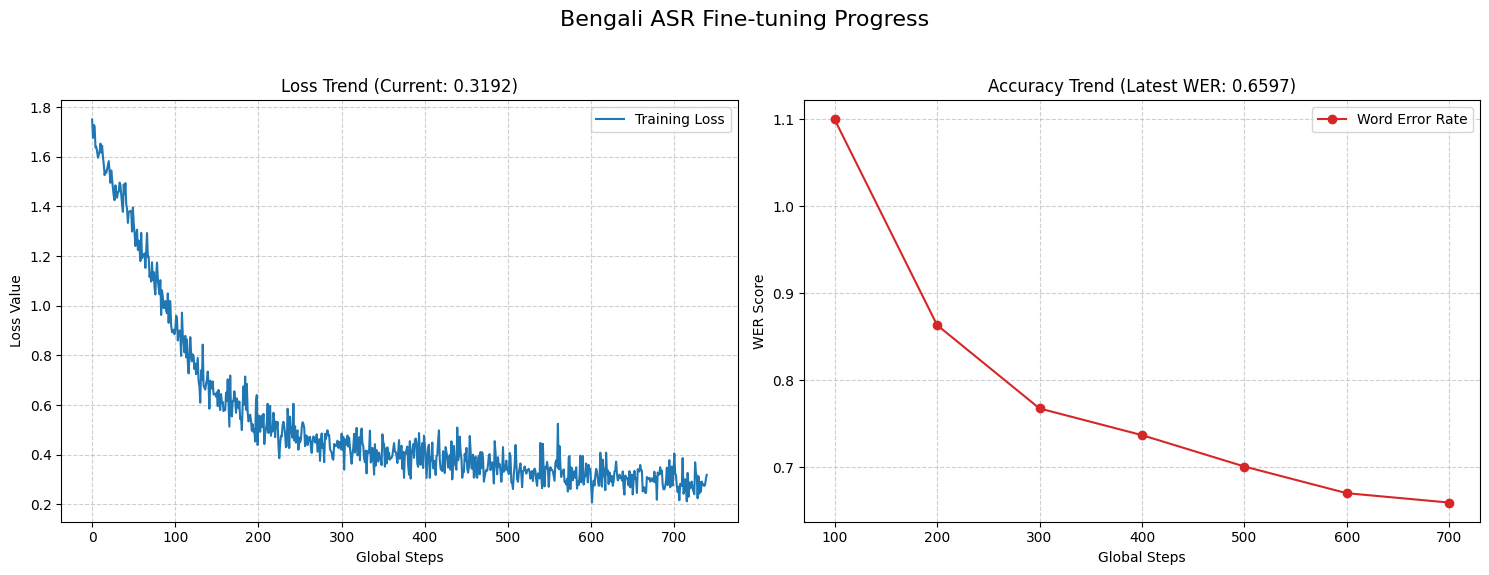

Step 740 | Epoch 2 | Loss: 0.3192
🎉 Training Complete!


In [ ]:
import torch
import matplotlib.pyplot as plt
import os
from tqdm.auto import tqdm
from IPython.display import clear_output

# --- CONFIGURATION ---
DRIVE_SAVE_PATH = "/content/drive/MyDrive/bengali_asr_checkpoints"
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# LoRA-specific optimizer: Only update trainable parameters
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

# Training Progress Trackers
running_loss = []
history_wer = []
history_steps = []
max_epochs = 2
eval_steps = 100
save_steps = 200

for epoch in range(max_epochs):
    model.train()
    # Use tqdm for the progress bar
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}")

    for step, batch in enumerate(progress_bar):
        # --- FIX: ROBUST DATA LOADING ---
        # Explicitly extract and move to device.
        # Using .to(device) here ensures input_features is a Tensor, not None.
        input_features = batch["input_features"].to(device)
        labels = batch["labels"].to(device)

        # --- FIX: EXPLICIT KEYWORD ARGUMENTS ---
        # Passing input_features as a keyword argument prevents positional errors
        outputs = model(input_features=input_features, labels=labels)

        loss = outputs.loss
        loss.backward()

        # Gradient clipping is recommended for ASR to prevent spikes
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        optimizer.zero_grad()

        global_step = len(running_loss) + 1
        running_loss.append(loss.item())

        # 1. VISUAL UPDATE (Loss & WER)
        if global_step % 20 == 0:
            clear_output(wait=True)
            plt.figure(figsize=(15, 6))
            plt.suptitle('Bengali ASR Fine-tuning Progress', fontsize=16)

            # Left Subplot: Loss
            plt.subplot(1, 2, 1)
            plt.plot(running_loss, color='#1f77b4', label='Training Loss')
            plt.title(f'Loss Trend (Current: {loss.item():.4f})')
            plt.xlabel('Global Steps')
            plt.ylabel('Loss Value')
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend()

            # Right Subplot: WER
            plt.subplot(1, 2, 2)
            if history_wer:
                plt.plot(history_steps, history_wer, marker='o', color='#d62728', label='Word Error Rate')
                plt.title(f'Accuracy Trend (Latest WER: {history_wer[-1]:.4f})')
            else:
                plt.title('Accuracy Trend (Waiting for Eval...)')
            plt.xlabel('Global Steps')
            plt.ylabel('WER Score')
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.legend()

            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

            print(f"Step {global_step} | Epoch {epoch+1} | Loss: {loss.item():.4f}")

        # 2. PERIODIC EVALUATION
        if global_step % eval_steps == 0:
            print(f"\n--- Running Fast Evaluation at Step {global_step} ---")
            # Ensure evaluation happens in eval mode
            model.eval()
            current_wer = fast_evaluation(model, test_data, tokenizer, feature_extractor, num_samples=100)
            history_wer.append(current_wer)
            history_steps.append(global_step)
            model.train() # Switch back to train mode

        # 3. PERMANENT SAVE TO DRIVE
        if global_step % save_steps == 0:
            save_dir = os.path.join(DRIVE_SAVE_PATH, f"lora_step_{global_step}")
            model.save_pretrained(save_dir)
            # Also save the processor/tokenizer for easy loading later
            tokenizer.save_pretrained(save_dir)
            print(f"✅ Secure Checkpoint saved to Drive: {save_dir}")

    # Clear GPU cache after each epoch to prevent fragmentation
    torch.cuda.empty_cache()

print("🎉 Training Complete!")


In [ ]:
from peft import PeftModel, PeftConfig
from transformers import WhisperForConditionalGeneration, WhisperProcessor
import torch

# 1. Load the BASE model again (using the same model ID you used for training)
base_model_id = "openai/whisper-small"
base_model = WhisperForConditionalGeneration.from_pretrained(base_model_id).to("cuda")

# 2. Load the LoRA adapters from your Drive
checkpoint_path = "/content/drive/MyDrive/bengali_asr_checkpoints/lora_step_600"
model = PeftModel.from_pretrained(base_model, checkpoint_path)

# 3. CRITICAL: Merge LoRA weights into the base model for faster inference
model = model.merge_and_unload()
model.eval()

print("✅ Model successfully merged and ready for inference!")

# 4. Quick Test Inference
sample = next(iter(test_data))
input_features = feature_extractor(sample["audio"]["array"], sampling_rate=16000, return_tensors="pt").input_features.to("cuda")

with torch.no_grad():
    predicted_ids = model.generate(input_features, language='bengali', task='transcribe')
    transcription = tokenizer.batch_decode(predicted_ids, skip_special_tokens=True)[0]

print(f"\n--- Inference Result ---")
print(f"Target Text: {sample['transcription']}")
print(f"Model Pred:  {transcription}")


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

✅ Model successfully merged and ready for inference!

--- Inference Result ---
Target Text: জার্মানির অনেক বেক করা খাবারগুলিতে বাদাম হ্যাজনেলট এবং অন্যান্য বাদামের উপাদান পাওয়া যায় পছন্দের কেকগুলি প্রায়শই একটি কাপ ভরা কফির সাথে ভাল মানায়
Model Pred:  জান্মানীর অনেক বেক করা খাবার গুলিতে বাদাম হেজনেল্ত এবং অন্নার্ন বাদামের উপাদাম পায়াজায় অছান্দের কেক্গুলি প্রায়সয় একটি কাব ভরা কফির সাতে ভালনায়


In [ ]:
from IPython.display import clear_output
torch.cuda.empty_cache()

model.train()

device=DEVICE

optimizer=torch.optim.AdamW(model.parameters(), lr=1e-5)
# optimizer=torch.optim.AdamW(requires_grad_params, lr=5e-4) # Only for LoRA Training

max_epochs=2


running_wer=[]
running_loss=[]



for epoch in range(max_epochs):

    for batch in tqdm(train_dataloader,total=len(train_dataloader),leave=False):

        model.train()  # Set model to training mode

        input_features, labels = batch["input_features"].to(device), batch["labels"].to(device)

        # Forward pass
        outputs = model(input_features, labels=labels)  # Assuming your model takes these inputs
        loss = outputs.loss

        # Backward pass and optimization
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()  # Reset gradients

        running_loss.append(loss.item())

        if len(running_loss) % 50 ==0:
            clear_output(wait=True)
            plt.plot(running_loss)
            plt.xlabel('steps')
            plt.ylabel('loss')
            plt.show()

        if len(running_loss) % 100 == 0:  # Save model every 100 steps
            # torch.save(model.state_dict(), f'finetuned_on_bengali_steps_{len(running_loss)}.pth')
            model.save_pretrained('lora_model')

    torch.cuda.empty_cache()
    wer_score = fast_evaluation(model, test_data, tokenizer, feature_extractor)
    running_wer.append(wer_score)

In [ ]:
model.load_state_dict(torch.load('finetuned_on_bengali_steps_1000.pth', weights_only=True))# loading the model
model.eval()
model.to('cuda')


torch.cuda.empty_cache()
evaluation(model)


In [ ]:
model.eval()

test_data = load_dataset("mozilla-foundation/common_voice_17_0", LANG_CODE, split="test")

for idx in range(5):

    target = test_data[idx]['sentence']
    audio_original = test_data[idx]['audio']['array']
    original_sample_rate = test_data[idx]['audio']['sampling_rate']

    audio_16000 = down_sample_audio(audio_original, original_sample_rate)

    input_feature = feature_extractor(raw_speech=audio_16000,
                                    sampling_rate=16000,
                                    return_tensors='pt').input_features

    with torch.no_grad():
        op = model.generate(input_feature.to('cuda'), language='bengali', task='transcribe')


    text_pred =  tokenizer.batch_decode(op,skip_special_tokens=True )[0]

    print(f'-------{idx}------')
    print(f'true : {target} \npred : {text_pred}')
    print('\n ')


In [ ]:
from transformers import pipeline

pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=tokenizer,
    feature_extractor=feature_extractor,
    chunk_length_s=30,
    stride_length_s=10,
    device='cuda',
)

In [ ]:
# Make sure 'bengali_audio_youtube.mp3' is replaced with a Bengali audio file for accurate evaluation.
result = pipe("bengali_audio_youtube.mp3")
result
